In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("cardio_train.csv", sep=';')
df
# outlier handling

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# 1. Checked and handled missing values

In [3]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

# 2. Removed duplicate rows

In [4]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Length: 70000, dtype: bool

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.duplicated().sum()

np.int64(0)

# 3. Fixed incorrect data types

In [8]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [9]:
df['age'] = df['age']/365;

In [10]:
df['age']

0        50.391781
1        55.419178
2        51.663014
3        48.282192
4        47.873973
           ...    
69995    52.712329
69996    61.920548
69997    52.235616
69998    61.454795
69999    56.273973
Name: age, Length: 70000, dtype: float64

# 4. Checked and treated outliers

In [11]:
# Outliers are mainly present in

# height
# weight
# ap_hi
# ap_lo

df[["height","weight","ap_hi","ap_lo"]].describe()

,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000
mean,164.359229,74.205690,128.817286,96.630414
std,8.210126,14.395757,154.011419,188.472530
min,55.000000,10.000000,-150.000000,-70.000000
25%,159.000000,65.000000,120.000000,80.000000
50%,165.000000,72.000000,120.000000,80.000000
75%,170.000000,82.000000,140.000000,90.000000
max,250.000000,200.000000,16020.000000,11000.000000


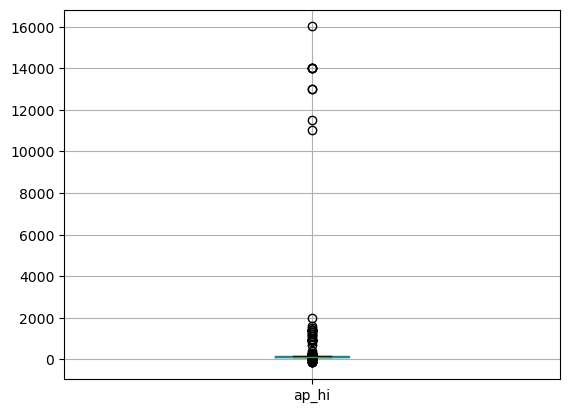

In [20]:
import matplotlib.pyplot as plt

df.boxplot(column="ap_hi")

plt.show()

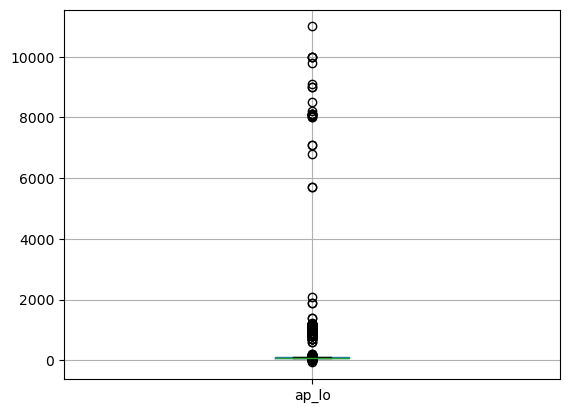

In [21]:
df.boxplot(column="ap_lo")

plt.show()

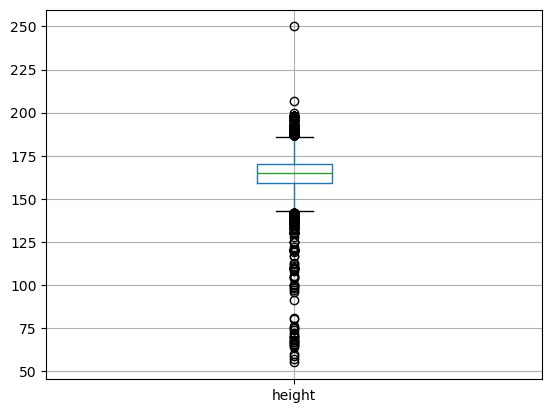

In [14]:
df.boxplot(column="height")

plt.show()

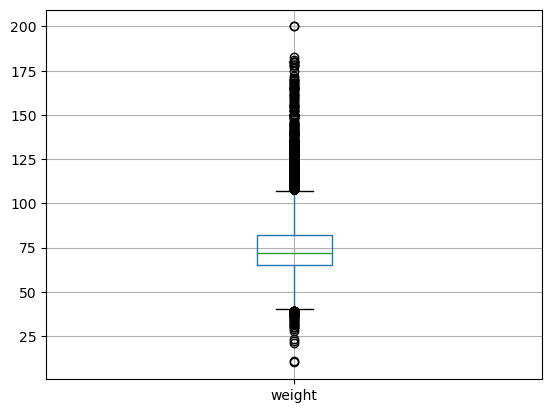

In [15]:
df.boxplot(column="weight")

plt.show()

# 5. Visualize numeric columns

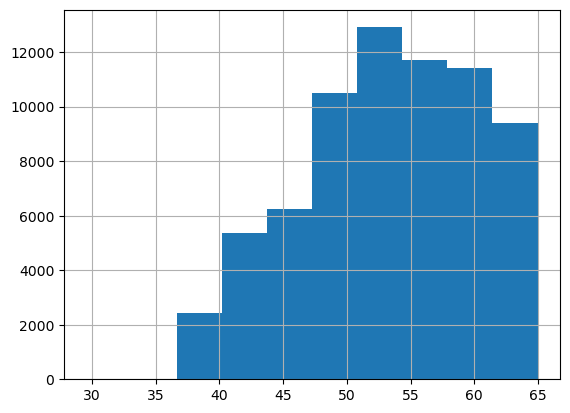

In [22]:

df["age"].hist()
plt.show()

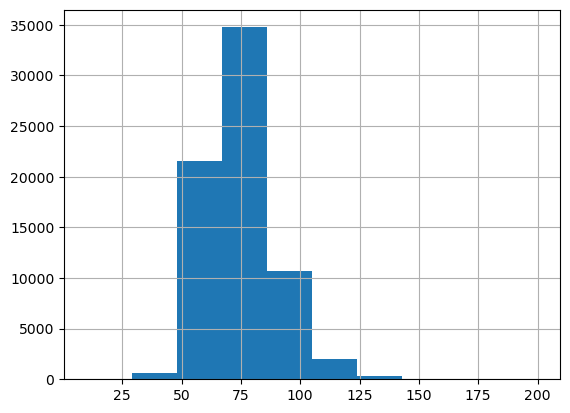

In [23]:
df["weight"].hist()
plt.show()

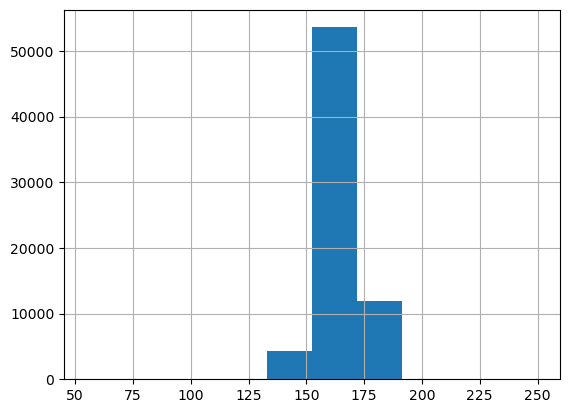

In [24]:
df["height"].hist()
plt.show()

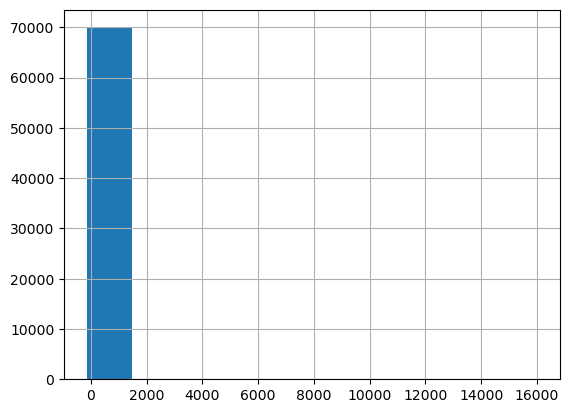

In [25]:
df["ap_hi"].hist()
plt.show()

# 6. Visualize categorical columns

In [26]:
df["gender"].value_counts()

gender
1    45530
2    24470
Name: count, dtype: int64

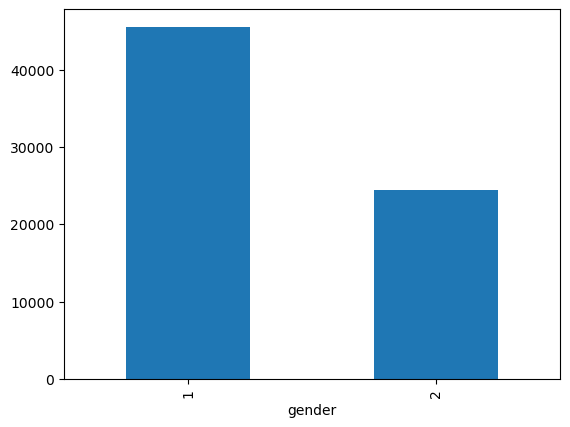

In [27]:
df["gender"].value_counts().plot(kind="bar")
plt.show()


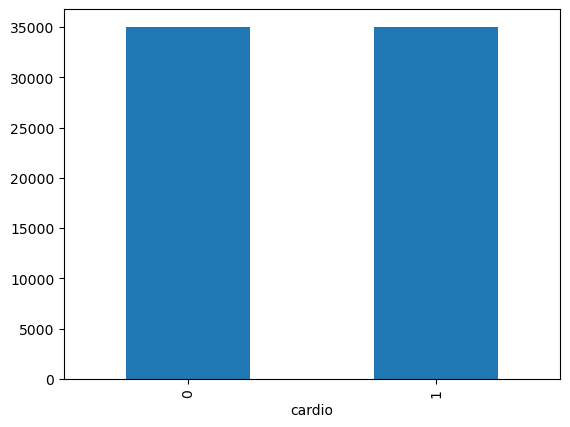

In [28]:
df["cardio"].value_counts().plot(kind="bar")
plt.show()

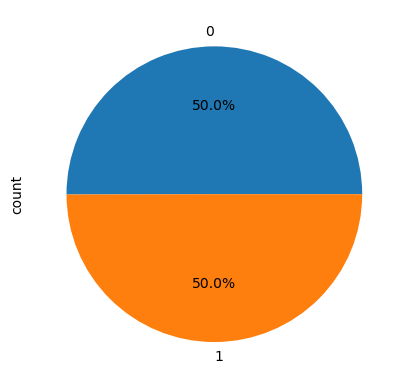

In [29]:
df["cardio"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

columns_to_scale = ["age", "height", "weight", "ap_hi", "ap_lo"]

scaler = StandardScaler()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [31]:
X_train.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
47339,67617,0.976386,1,-1.263910,0.404666,0.008508,-0.035487,2,1,0,0,1
67456,96320,-1.112800,2,-0.286798,-0.291664,0.075919,-0.035487,1,1,0,0,0
12308,17571,0.673477,2,1.178871,1.240262,0.143330,0.015024,1,1,0,0,1
32557,46492,1.579776,2,1.056732,0.126134,-0.058903,-0.075896,1,1,0,0,1
664,945,0.330476,1,-0.531076,-0.987993,-0.058903,-0.085998,1,1,0,0,1


In [32]:
print(X_train[columns_to_scale].mean())

age       2.908150e-16
height   -1.256011e-15
weight   -1.004022e-15
ap_hi    -6.382196e-17
ap_lo     1.497215e-17
dtype: float64


In [33]:
print(X_train[columns_to_scale].std())

age       1.000009
height    1.000009
weight    1.000009
ap_hi     1.000009
ap_lo     1.000009
dtype: float64


In [34]:
print(df[columns_to_scale].head())

         age  height  weight  ap_hi  ap_lo
0  50.391781     168    62.0    110     80
1  55.419178     156    85.0    140     90
2  51.663014     165    64.0    130     70
3  48.282192     169    82.0    150    100
4  47.873973     156    56.0    100     60


In [35]:
df['BMI']= df['weight']/((df['height']/100)**2)

df['BMI']

0        21.967120
1        34.927679
2        23.507805
3        28.710479
4        23.011177
           ...    
69995    26.927438
69996    50.472681
69997    31.353579
69998    27.099251
69999    24.913495
Name: BMI, Length: 70000, dtype: float64

In [36]:
df['bmi_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'], right=False)

In [37]:
df['bmi_category']

0        Normal weight
1                Obese
2        Normal weight
3           Overweight
4        Normal weight
             ...      
69995       Overweight
69996            Obese
69997            Obese
69998       Overweight
69999    Normal weight
Name: bmi_category, Length: 70000, dtype: category
Categories (4, object): ['Underweight' < 'Normal weight' < 'Overweight' < 'Obese']

In [38]:
print(df.duplicated().sum())

0


In [39]:
df=df.drop_duplicates()

In [40]:
print(df.duplicated().sum())

0


# 7. Final model-ready preprocessing


In [41]:
# Convert age from days to years, matching the model input used by the application.
df = df.copy()
df['age'] = (df['age'] / 365).astype(int)

# BMI is already calculated above. Remove only the categorical BMI helper column.
df = df.drop(columns=['bmi_category'], errors='ignore')

# Remove the identifier column before creating the final feature matrix.
df = df.drop(columns=['id'], errors='ignore')

X = df.drop(columns=['cardio'])
y = df['cardio']


In [42]:
# Final feature names used by the prediction model
print('Feature columns:')
print(X.columns.tolist())
print('\nNumber of features:', X.shape[1])


Feature columns:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']

Number of features: 12


In [43]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI'],
      dtype='object')

In [44]:
# Train/test split for the final model-ready dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Split raw data; do not scale it manually
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Pipeline: it scales data first, then trains the model
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train pipeline
model_pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = model_pipeline.predict(X_test)

In [45]:
import joblib
from pathlib import Path

model_file = Path(
    r"C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project"
) / "cardiovascular_logistic_regression_pipeline.pkl"

joblib.dump(model_pipeline, model_file)

print("Saved successfully:", model_file)
print("File exists:", model_file.exists())

Saved successfully: C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project\cardiovascular_logistic_regression_pipeline.pkl
File exists: True


In [46]:
import sklearn
print(sklearn.__version__)

1.6.1


In [47]:
import sys
print(sys.executable)

C:\Users\ASUS\anaconda3\python.exe


In [48]:
import sys
import subprocess

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "show",
    "scikit-learn"
])

CompletedProcess(args=['C:\\Users\\ASUS\\anaconda3\\python.exe', '-m', 'pip', 'show', 'scikit-learn'], returncode=0)

In [49]:
import joblib

model = joblib.load("cardiovascular_logistic_regression_pipeline.pkl")

print(type(model))
print(model.feature_names_in_)

<class 'sklearn.pipeline.Pipeline'>
['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'BMI']


In [50]:
import sys
import sklearn

print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

Python: C:\Users\ASUS\anaconda3\python.exe
scikit-learn: 1.6.1


In [51]:
import os

print(os.path.abspath("cardiovascular_logistic_regression_pipeline.pkl"))

C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project\cardiovascular_logistic_regression_pipeline.pkl


In [52]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load fresh dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# Remove ID before creating X
df = df.drop(columns="id")

# Convert age from days to years
df["age"] = (df["age"] / 365.25).astype(int)

# Create BMI
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaler and model together
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
model_pipeline.fit(X_train, y_train)

# Confirm input features
print(model_pipeline.feature_names_in_)

['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'BMI']


In [53]:
joblib.dump(
    model_pipeline,
    r"C:\Users\ASUS\OneDrive\Desktop\Sem5\ML\Project\cardiovascular_logistic_regression_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Model Evaluation

# The trained Logistic Regression model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict test data
y_pred = model_pipeline.predict(X_test)
# Calculate evalution metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)

# Display Result

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1_score* 100, 2), "%")

Accuracy : 71.39 %
Precision: 73.16 %
Recall   : 67.51 %
F1-Score : 70.22 %


In [55]:
# Confusion Matrix

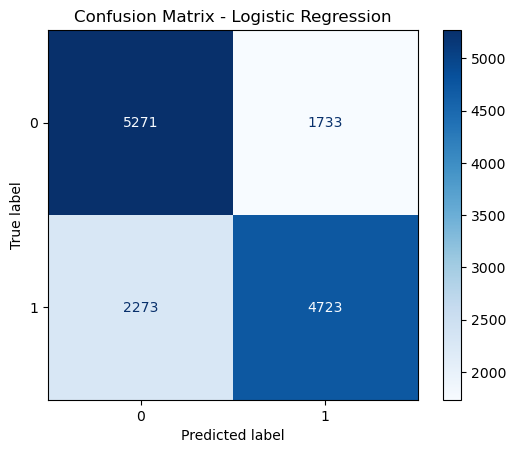

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 2. Check Overfitting / Underfitting [BOTH]

Compare **Train Accuracy** vs **Test Accuracy** to diagnose model fit:
- Train score >> Test score → **Overfitting**
- Both scores low → **Underfitting**
- Train ≈ Test scores → **Good Fit ✅**

In [57]:
from sklearn.metrics import accuracy_score

# Predict on TRAIN set (data the model SAW during training)
y_train_pred = model_pipeline.predict(X_train)

# Predict on TEST set (data the model NEVER saw)
y_test_pred = model_pipeline.predict(X_test)

# Calculate Train and Test accuracy
train_score = accuracy_score(y_train, y_train_pred) * 100
test_score  = accuracy_score(y_test,  y_test_pred)  * 100

print(f"Train Accuracy : {train_score:.2f}%")
print(f"Test  Accuracy : {test_score:.2f}%")
print(f"Difference     : {abs(train_score - test_score):.2f}%")
print()

# Interpret the result
if train_score - test_score > 5:
    print("Warning: OVERFITTING - Train score is much higher than Test score.")
elif train_score < 70 and test_score < 70:
    print("Warning: UNDERFITTING - Both Train and Test scores are low.")
else:
    print("GOOD FIT: Train and Test scores are close to each other.")

Train Accuracy : 72.03%
Test  Accuracy : 71.39%
Difference     : 0.65%

GOOD FIT: Train and Test scores are close to each other.


## 3. Cross-Validation (5-Fold) [BOTH]

Cross-validation gives a **reliable estimate** of model performance by training and
testing on **different splits** of the data:
- **Average CV Score** → overall model performance
- **Score Spread (std)** → high spread = unstable model, low spread = stable model

We run **5-fold CV** on the **full dataset** using the same pipeline (Scaler + LogisticRegression).

In [58]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Use Stratified K-Fold to preserve class balance in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold CV on the FULL dataset (X, y) using the same pipeline
cv_scores = cross_val_score(
    model_pipeline,
    X,               # full feature matrix
    y,               # full target
    cv=skf,
    scoring='accuracy'
)

# Convert to percentage
cv_scores_pct = cv_scores * 100

print("5-Fold Cross-Validation Results")
print("-" * 35)
for i, score in enumerate(cv_scores_pct, 1):
    print(f"  Fold {i}: {score:.2f}%")
print("-" * 35)
print(f"  Mean  Accuracy : {cv_scores_pct.mean():.2f}%")
print(f"  Std   Deviation: {cv_scores_pct.std():.2f}%")
print(f"  Min   Score    : {cv_scores_pct.min():.2f}%")
print(f"  Max   Score    : {cv_scores_pct.max():.2f}%")
print()

# Interpret spread
if cv_scores_pct.std() > 3:
    print("Warning: HIGH SPREAD - Model may be unstable across different data splits.")
else:
    print("LOW SPREAD - Model is stable and consistent across all folds.")

5-Fold Cross-Validation Results
-----------------------------------
  Fold 1: 72.41%
  Fold 2: 71.79%
  Fold 3: 72.52%
  Fold 4: 72.21%
  Fold 5: 71.82%
-----------------------------------
  Mean  Accuracy : 72.15%
  Std   Deviation: 0.30%
  Min   Score    : 71.79%
  Max   Score    : 72.52%

LOW SPREAD - Model is stable and consistent across all folds.


In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# model_pipeline is already trained above
train_score = model_pipeline.score(X_train, y_train) * 100
test_score  = model_pipeline.score(X_test,  y_test)  * 100
diff        = abs(train_score - test_score)

print(f'Train Accuracy : {train_score:.2f}%')
print(f'Test  Accuracy : {test_score:.2f}%')
print(f'Difference     : {diff:.2f}%')

if diff < 3:
    verdict = 'Good Fit — Train and Test scores are very close. ✅'
elif train_score > test_score + 5:
    verdict = 'Overfitting — Train score is significantly higher than Test score. ⚠️'
else:
    verdict = 'Underfitting — Both scores are low. ⚠️'

print(f'Verdict        : {verdict}')

Train Accuracy : 72.03%
Test  Accuracy : 71.39%
Difference     : 0.65%
Verdict        : Good Fit — Train and Test scores are very close. ✅


In [60]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_pipeline, X, y, cv=cv, scoring='accuracy') * 100

print('Per-fold Accuracy:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.2f}%')

print(f'\nMean  : {cv_scores.mean():.2f}%')
print(f'Std   : {cv_scores.std():.2f}%')
print(f'Range : {cv_scores.min():.2f}% – {cv_scores.max():.2f}%')

stability = 'Stable ✅ (low spread)' if cv_scores.std() < 1.0 else 'Unstable ⚠️ (high spread)'
print(f'Model Stability: {stability}')

Per-fold Accuracy:
  Fold 1: 72.41%
  Fold 2: 71.79%
  Fold 3: 72.52%
  Fold 4: 72.21%
  Fold 5: 71.82%

Mean  : 72.15%
Std   : 0.30%
Range : 71.79% – 72.52%
Model Stability: Stable ✅ (low spread)


In [61]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbours': KNeighborsClassifier(n_jobs=-1),
}

results = []
for name, clf in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred)  * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred)    * 100, 2),
        'F1-Score' : round(f1_score(y_test, y_pred)        * 100, 2),
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]['Model']
best_f1   = results_df.iloc[0]['F1-Score']
print(f'\n🏆 Best Model: {best_name}  (F1 = {best_f1}%)')

               Model  Accuracy  Precision  Recall  F1-Score
   Gradient Boosting     73.57      75.18   70.34     72.68
       Random Forest     71.04      71.33   70.28     70.80
 Logistic Regression     71.39      73.16   67.51     70.22
         Extra Trees     69.58      69.50   69.73     69.61
K-Nearest Neighbours     64.47      65.09   62.35     63.69
       Decision Tree     63.27      63.62   61.88     62.74

🏆 Best Model: Gradient Boosting  (F1 = 72.68%)


In [62]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── 5a. GridSearchCV — Logistic Regression ──────────────────────────
print('-- GridSearchCV: Logistic Regression --')

param_grid_lr = {
    'model__C'      : [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver' : ['liblinear'],
}

grid_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('model',  LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

y_pred_lr = grid_lr.best_estimator_.predict(X_test)
print(f'Best params  : {grid_lr.best_params_}')
print(f'Accuracy     : {accuracy_score(y_test, y_pred_lr)*100:.2f}%')
print(f'F1-Score     : {f1_score(y_test, y_pred_lr)*100:.2f}%')
print(f'(Baseline LR): Accuracy={test_score:.2f}%')

-- GridSearchCV: Logistic Regression --
Best params  : {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Accuracy     : 71.44%
F1-Score     : 70.27%
(Baseline LR): Accuracy=71.39%


In [63]:
# ── 5b. RandomizedSearchCV — Random Forest ──────────────────────────
print('-- RandomizedSearchCV: Random Forest --')

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# Smaller parameter space for faster execution
param_dist_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rand_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=5,          # reduced from 10
    cv=3,              # reduced from 5
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

rand_rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rand_rf.best_estimator_.predict(X_test)

print(f'Best params  : {rand_rf.best_params_}')
print(f'Accuracy     : {accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(f'F1-Score     : {f1_score(y_test, y_pred_rf)*100:.2f}%')


# ── Summary ─────────────────────────────────────────────────────────
print('\n-- Tuning Summary --')

summary = pd.DataFrame([
    {
        'Model': 'LR (baseline)',
        'F1': round(
            f1_score(y_test, model_pipeline.predict(X_test)) * 100, 2
        )
    },
    {
        'Model': 'LR (GridSearchCV)',
        'F1': round(f1_score(y_test, y_pred_lr) * 100, 2)
    },
    {
        'Model': 'RF (baseline)',
        'F1': round(
            results_df[
                results_df.Model == "Random Forest"
            ]['F1-Score'].values[0],
            2
        )
    },
    {
        'Model': 'RF (RandomizedSearch)',
        'F1': round(f1_score(y_test, y_pred_rf) * 100, 2)
    },
])

print(summary.to_string(index=False))

-- RandomizedSearchCV: Random Forest --
Best params  : {'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10}
Accuracy     : 73.36%
F1-Score     : 72.03%

-- Tuning Summary --
                Model    F1
        LR (baseline) 70.22
    LR (GridSearchCV) 70.27
        RF (baseline) 70.80
RF (RandomizedSearch) 72.03


## Task 5 - Section 4: Compare All Models
Train several classifiers on the same train/test split and compare
Accuracy, Precision, Recall, and F1-Score in a single table.
Pick the model with the best score AND stable cross-validation result.

In [64]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ── All models to compare ──────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=50,       # reduced from 100
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,       # reduced from 100
        random_state=42
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=50,       # reduced from 100
        random_state=42,
        n_jobs=-1
    ),

    'K-Nearest Neighbours': KNeighborsClassifier(
        n_jobs=-1
    ),
}


# ── Train and evaluate ─────────────────────────────────────────────
results = []
trained_pipelines = {}

for name, clf in models.items():

    print(f'Training {name}...')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', clf)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    trained_pipelines[name] = pipe

    results.append({
        'Model': name,
        'Accuracy': round(
            accuracy_score(y_test, y_pred) * 100, 2
        ),
        'Precision': round(
            precision_score(y_test, y_pred, zero_division=0) * 100, 2
        ),
        'Recall': round(
            recall_score(y_test, y_pred, zero_division=0) * 100, 2
        ),
        'F1-Score': round(
            f1_score(y_test, y_pred, zero_division=0) * 100, 2
        )
    })


# ── Create result table ─────────────────────────────────────────────
results_df = (
    pd.DataFrame(results)
    .sort_values('F1-Score', ascending=False)
    .reset_index(drop=True)
)

print('\n-- Model Comparison --')
print(results_df.to_string(index=False))


# ── Best model ──────────────────────────────────────────────────────
best_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']

print(f'\nBest Model : {best_name}  (F1 = {best_f1}%)')
print('Pick the model with best score AND stable cross-validation result.')

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Extra Trees...
Training K-Nearest Neighbours...

-- Model Comparison --
               Model  Accuracy  Precision  Recall  F1-Score
   Gradient Boosting     73.14      74.89   69.58     72.14
       Random Forest     70.84      71.21   69.93     70.56
 Logistic Regression     71.39      73.16   67.51     70.22
         Extra Trees     69.37      69.46   69.08     69.27
K-Nearest Neighbours     64.47      65.09   62.35     63.69
       Decision Tree     63.27      63.62   61.88     62.74

Best Model : Gradient Boosting  (F1 = 72.14%)
Pick the model with best score AND stable cross-validation result.


## Task 5 - Section 5: Hyperparameter Tuning
Use **GridSearchCV** on Logistic Regression and **RandomizedSearchCV** on Random Forest.
Try different values of key settings and note the best combination found.
Re-test the tuned model on the test set and confirm the score improved.

In [65]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── 5a. GridSearchCV on Logistic Regression ─────────────────────────
print('--- GridSearchCV: Logistic Regression ---')
print('Trying different values of: C, penalty')

param_grid_lr = {
    'model__C'      : [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver' : ['liblinear'],
}

grid_lr = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('model',  LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

y_pred_lr_base  = trained_pipelines['Logistic Regression'].predict(X_test)
y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test)

print(f'Best combination found : {grid_lr.best_params_}')
print(f'Before tuning -> Accuracy={accuracy_score(y_test,y_pred_lr_base)*100:.2f}%  '
      f'F1={f1_score(y_test,y_pred_lr_base)*100:.2f}%')
print(f'After  tuning -> Accuracy={accuracy_score(y_test,y_pred_lr_tuned)*100:.2f}%  '
      f'F1={f1_score(y_test,y_pred_lr_tuned)*100:.2f}%')

--- GridSearchCV: Logistic Regression ---
Trying different values of: C, penalty
Best combination found : {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Before tuning -> Accuracy=71.39%  F1=70.22%
After  tuning -> Accuracy=71.44%  F1=70.27%


In [68]:
# ── 5b. RandomizedSearchCV on Random Forest ──────────────────────────
print('--- RandomizedSearchCV: Random Forest ---')

print('Trying different values of: n_estimators, max_depth, '
      'max_features, min_samples_split, min_samples_leaf')

# Smaller parameter space = faster execution
param_dist_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20],
    'model__max_features': ['sqrt', 'log2'],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

# Randomized Search
rand_rf = RandomizedSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]),
    param_distributions=param_dist_rf,

    n_iter=5,       # was 10
    cv=3,           # was 5

    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1       # shows progress while running
)

# Train
rand_rf.fit(X_train, y_train)


# ── Predictions ─────────────────────────────────────────────────────

# Random Forest before tuning
y_pred_rf_base = trained_pipelines[
    'Random Forest'
].predict(X_test)

# Random Forest after tuning
y_pred_rf_tuned = rand_rf.best_estimator_.predict(X_test)


# ── Results ──────────────────────────────────────────────────────────

print('\nBest combination found:')
print(rand_rf.best_params_)

print(
    f'\nBefore tuning -> '
    f'Accuracy={accuracy_score(y_test, y_pred_rf_base)*100:.2f}%  '
    f'F1={f1_score(y_test, y_pred_rf_base)*100:.2f}%'
)

print(
    f'After tuning  -> '
    f'Accuracy={accuracy_score(y_test, y_pred_rf_tuned)*100:.2f}%  '
    f'F1={f1_score(y_test, y_pred_rf_tuned)*100:.2f}%'
)


# ── Final summary table ──────────────────────────────────────────────

print('\n--- Tuning Summary ---')

summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression (baseline)',
        'F1-Score': round(
            f1_score(y_test, y_pred_lr_base) * 100, 2
        )
    },
    {
        'Model': 'Logistic Regression (GridSearchCV)',
        'F1-Score': round(
            f1_score(y_test, y_pred_lr_tuned) * 100, 2
        )
    },
    {
        'Model': 'Random Forest (baseline)',
        'F1-Score': round(
            f1_score(y_test, y_pred_rf_base) * 100, 2
        )
    },
    {
        'Model': 'Random Forest (RandomizedSearchCV)',
        'F1-Score': round(
            f1_score(y_test, y_pred_rf_tuned) * 100, 2
        )
    }
])

print(summary.to_string(index=False))

--- RandomizedSearchCV: Random Forest ---
Trying different values of: n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best combination found:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10}

Before tuning -> Accuracy=70.84%  F1=70.56%
After tuning  -> Accuracy=73.36%  F1=72.03%

--- Tuning Summary ---
                             Model  F1-Score
    Logistic Regression (baseline)     70.22
Logistic Regression (GridSearchCV)     70.27
          Random Forest (baseline)     70.56
Random Forest (RandomizedSearchCV)     72.03
